In [2]:
import pandas as pd

emissions = pd.read_csv('/content/data/raw/emissions_raw.csv')
demand = pd.read_csv('/content/data/raw/demand_raw.csv')

print("EMISSIONS COLUMNS:", emissions.columns.tolist())
print("DEMAND COLUMNS:", demand.columns.tolist())

print("\nEMISSIONS HEAD")
print(emissions.head())
print("\nEMISSIONS INFO")
print(emissions.info())


print("\nDEMAND HEAD")
print(demand.head())
print("\nDEMAND INFO")
print(demand.info())

EMISSIONS COLUMNS: ['point_time', 'value', 'region', 'source_window']
DEMAND COLUMNS: ['timestamp', 'balancing_authority', 'demand_MW', 'source_window']

EMISSIONS HEAD
                  point_time  value       region      source_window
0  2024-04-01T00:00:00+00:00    0.0  CAISO_NORTH  2024_summer_caiso
1  2024-04-01T00:05:00+00:00    0.0  CAISO_NORTH  2024_summer_caiso
2  2024-04-01T00:10:00+00:00    0.0  CAISO_NORTH  2024_summer_caiso
3  2024-04-01T00:15:00+00:00    0.0  CAISO_NORTH  2024_summer_caiso
4  2024-04-01T00:20:00+00:00    0.0  CAISO_NORTH  2024_summer_caiso

EMISSIONS INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52711 entries, 0 to 52710
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   point_time     52711 non-null  object 
 1   value          52711 non-null  float64
 2   region         52711 non-null  object 
 3   source_window  52711 non-null  object 
dtypes: float64(1), object(3)
memor

## Step 1: Convert timestamps and rename columns

In [3]:
# Convert timestamps
emissions['point_time'] = pd.to_datetime(emissions['point_time'], utc=True)
demand['timestamp'] = pd.to_datetime(demand['timestamp']).dt.tz_localize('UTC')

# Rename columns
emissions = emissions.rename(columns={
    'point_time': 'timestamp',
    'value': 'moer'
})

# Sort
emissions = emissions.sort_values('timestamp')
demand = demand.sort_values('timestamp')

print(emissions.head())
print(demand.head())

                  timestamp  moer       region      source_window
0 2024-04-01 00:00:00+00:00   0.0  CAISO_NORTH  2024_summer_caiso
1 2024-04-01 00:05:00+00:00   0.0  CAISO_NORTH  2024_summer_caiso
2 2024-04-01 00:10:00+00:00   0.0  CAISO_NORTH  2024_summer_caiso
3 2024-04-01 00:15:00+00:00   0.0  CAISO_NORTH  2024_summer_caiso
4 2024-04-01 00:20:00+00:00   0.0  CAISO_NORTH  2024_summer_caiso
                  timestamp balancing_authority  demand_MW      source_window
0 2024-04-01 00:00:00+00:00                CISO      17971  2024_summer_caiso
1 2024-04-01 01:00:00+00:00                CISO      17716  2024_summer_caiso
2 2024-04-01 02:00:00+00:00                CISO      18816  2024_summer_caiso
3 2024-04-01 03:00:00+00:00                CISO      20554  2024_summer_caiso
4 2024-04-01 04:00:00+00:00                CISO      22641  2024_summer_caiso


## Step 2: Resample demand to match emissions resolution

In [4]:
demand_15 = (
    demand.set_index('timestamp')
          .resample('15min')
          .ffill()
          .reset_index()
)

print(demand_15.head())

                  timestamp balancing_authority  demand_MW      source_window
0 2024-04-01 00:00:00+00:00                CISO      17971  2024_summer_caiso
1 2024-04-01 00:15:00+00:00                CISO      17971  2024_summer_caiso
2 2024-04-01 00:30:00+00:00                CISO      17971  2024_summer_caiso
3 2024-04-01 00:45:00+00:00                CISO      17971  2024_summer_caiso
4 2024-04-01 01:00:00+00:00                CISO      17716  2024_summer_caiso


## Step 3: Merge datasets

In [5]:
df = pd.merge(emissions, demand_15, on='timestamp', how='inner')

print("Merged shape:", df.shape)
df.head()

Merged shape: (17575, 7)


,timestamp,moer,region,source_window_x,balancing_authority,demand_MW,source_window_y
0,2024-04-01 00:00:00+00:00,0.0,CAISO_NORTH,2024_summer_caiso,CISO,17971,2024_summer_caiso
1,2024-04-01 00:15:00+00:00,0.0,CAISO_NORTH,2024_summer_caiso,CISO,17971,2024_summer_caiso
2,2024-04-01 00:30:00+00:00,998.1,CAISO_NORTH,2024_summer_caiso,CISO,17971,2024_summer_caiso
3,2024-04-01 00:45:00+00:00,1004.7,CAISO_NORTH,2024_summer_caiso,CISO,17971,2024_summer_caiso
4,2024-04-01 01:00:00+00:00,860.7,CAISO_NORTH,2024_summer_caiso,CISO,17716,2024_summer_caiso


## Step 4: Remove invalid MOER values

In [6]:
# Remove zeros (important)
df = df[df['moer'] > 0]

print("After cleaning:", df.shape)

After cleaning: (13520, 7)


## Step 5: Create rolling baseline and z-scores

In [7]:
window = 288  # 24 hours for 5-min data

df['demand_mean'] = df['demand_MW'].rolling(window).mean()
df['demand_std'] = df['demand_MW'].rolling(window).std()

df['moer_mean'] = df['moer'].rolling(window).mean()
df['moer_std'] = df['moer'].rolling(window).std()

df['demand_z'] = (df['demand_MW'] - df['demand_mean']) / df['demand_std']
df['moer_z'] = (df['moer'] - df['moer_mean']) / df['moer_std']

## Step 6: Detect anomalies

In [8]:
df['is_anomaly'] = (
    (df['demand_z'] > 2) &
    (df['moer_z'] > 1)
)

print(df['is_anomaly'].value_counts())

is_anomaly
False    13463
True        57
Name: count, dtype: int64


## Step 7: Convert anomalies into events

In [9]:
df['prev'] = df['is_anomaly'].shift(1, fill_value=False)
df['new_event'] = (df['is_anomaly']) & (~df['prev'])

df['event_id'] = df['new_event'].cumsum()

events_df = df[df['is_anomaly']].copy()

print("Detected events:", events_df['event_id'].nunique())

Detected events: 23


## Step 8: Create event-level dataset

In [10]:
event_features = (
    events_df.groupby('event_id')
    .agg(
        start_time=('timestamp','min'),
        end_time=('timestamp','max'),
        peak_demand=('demand_MW','max'),
        avg_demand=('demand_MW','mean'),
        peak_moer=('moer','max'),
        avg_moer=('moer','mean'),
        duration=('timestamp','count')
    )
    .reset_index()
)

event_features['duration_hours'] = event_features['duration'] * 5 / 60

print("Event dataset shape:", event_features.shape)
event_features.head()

Event dataset shape: (23, 9)


,event_id,start_time,end_time,peak_demand,avg_demand,peak_moer,avg_moer,duration,duration_hours
0,1,2024-04-16 05:00:00+00:00,2024-04-16 05:15:00+00:00,24779,24779.0,1056.5,1055.700,2,0.166667
1,2,2024-06-05 04:30:00+00:00,2024-06-05 04:30:00+00:00,32648,32648.0,1022.3,1022.300,1,0.083333
2,3,2024-06-05 05:00:00+00:00,2024-06-05 05:45:00+00:00,32621,32621.0,1028.9,1023.525,4,0.333333
3,4,2024-06-05 06:15:00+00:00,2024-06-05 06:30:00+00:00,31736,31736.0,1024.7,1023.600,2,0.166667
4,5,2024-06-06 00:30:00+00:00,2024-06-06 00:45:00+00:00,31929,31929.0,1027.8,1027.250,2,0.166667


In [11]:
# Create folder if needed
import os
os.makedirs("data/processed", exist_ok=True)

# Save event dataset
event_features.to_csv("data/processed/event_features.csv", index=False)

print("Saved event_features.csv successfully!")

Saved event_features.csv successfully!


# 1. Classification Model: Predicting High-Emission Grid Events

In this section, we implement a binary classification model to predict whether an automatically detected grid stress event corresponds to a high-emission event.

This directly supports our research question: can event-level demand characteristics help identify which grid stress events are associated with unusually high marginal CO₂ emissions?

## Step 1: Import Libraries

We begin by importing the libraries required for data preparation, model training, cross-validation, evaluation, and visualization.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

## Step 2: Inspect the Event-Level Dataset

We inspect the event-level dataset generated from the automatic event detection pipeline. Each row in this dataset represents one detected grid stress event.

In [13]:
print("Event-level dataset shape:", event_features.shape)
print(event_features.columns.tolist())
display(event_features.head())

Event-level dataset shape: (23, 9)
['event_id', 'start_time', 'end_time', 'peak_demand', 'avg_demand', 'peak_moer', 'avg_moer', 'duration', 'duration_hours']


,event_id,start_time,end_time,peak_demand,avg_demand,peak_moer,avg_moer,duration,duration_hours
0,1,2024-04-16 05:00:00+00:00,2024-04-16 05:15:00+00:00,24779,24779.0,1056.5,1055.700,2,0.166667
1,2,2024-06-05 04:30:00+00:00,2024-06-05 04:30:00+00:00,32648,32648.0,1022.3,1022.300,1,0.083333
2,3,2024-06-05 05:00:00+00:00,2024-06-05 05:45:00+00:00,32621,32621.0,1028.9,1023.525,4,0.333333
3,4,2024-06-05 06:15:00+00:00,2024-06-05 06:30:00+00:00,31736,31736.0,1024.7,1023.600,2,0.166667
4,5,2024-06-06 00:30:00+00:00,2024-06-06 00:45:00+00:00,31929,31929.0,1027.8,1027.250,2,0.166667


## Step 3: Define the Classification Target

To convert this into a supervised learning problem, we define a binary target variable indicating whether an event is a high-emission event.

Events with peak MOER above the 60th percentile are labeled as 1, while the rest are labeled as 0. A 60th percentile threshold is used instead of a stricter threshold to reduce class imbalance in our small dataset.

In [14]:
threshold = event_features['peak_moer'].quantile(0.60)

event_features['high_emission'] = (
    event_features['peak_moer'] > threshold
).astype(int)

print("Peak MOER threshold:", threshold)
print("\nClass distribution:")
print(event_features['high_emission'].value_counts())

Peak MOER threshold: 1030.1000000000001

Class distribution:
high_emission
0    14
1     9
Name: count, dtype: int64


## Step 4: Engineer Predictive Features

We create a small set of demand-based and duration-based predictors. This avoids emissions-based leakage and ensures the model is learning from operational signals rather than directly from the target itself.

In [15]:
event_features = event_features.copy()

event_features['demand_range'] = (
    event_features['peak_demand'] - event_features['avg_demand']
)

features = [
    'peak_demand',
    'avg_demand',
    'duration_hours',
    'demand_range'
]

target = 'high_emission'

X = event_features[features]
y = event_features[target]

display(event_features[features + [target]].head())

,peak_demand,avg_demand,duration_hours,demand_range,high_emission
0,24779,24779.0,0.166667,0.0,1
1,32648,32648.0,0.083333,0.0,0
2,32621,32621.0,0.333333,0.0,0
3,31736,31736.0,0.166667,0.0,0
4,31929,31929.0,0.166667,0.0,0


## Step 5: Build the Classification Pipeline

We use Logistic Regression as the primary classification model because it is simple, interpretable, and less prone to overfitting on small datasets.

To make the model robust, we:
- impute missing values if needed
- standardize the numeric features
- use class balancing

In [16]:
model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

model

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

## Step 6: Evaluate with Stratified Cross-Validation

Because the dataset is small, a single train-test split may produce unstable results. Instead, we use stratified 5-fold cross-validation so that each fold preserves class balance and the evaluation is more reliable.

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_results = cross_validate(
    model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

results_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC'],
    'Mean': [
        cv_results['test_accuracy'].mean(),
        cv_results['test_precision'].mean(),
        cv_results['test_recall'].mean(),
        cv_results['test_f1'].mean(),
        cv_results['test_roc_auc'].mean()
    ],
    'Std': [
        cv_results['test_accuracy'].std(),
        cv_results['test_precision'].std(),
        cv_results['test_recall'].std(),
        cv_results['test_f1'].std(),
        cv_results['test_roc_auc'].std()
    ]
})

display(results_df)

,Metric,Mean,Std
0,Accuracy,0.480000,0.074833
1,Precision,0.280000,0.231517
2,Recall,0.400000,0.374166
3,F1-score,0.314286,0.257935
4,ROC-AUC,0.650000,0.169967


## Step 7: Fit the Final Model on the Full Dataset

After evaluating the model with cross-validation, we fit it on the full dataset to inspect feature coefficients and generate prediction-based visualizations.

In [18]:
model.fit(X, y)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

## Step 8: Interpret Feature Effects

Logistic Regression allows us to inspect standardized coefficients. Positive coefficients indicate that larger feature values increase the probability of an event being classified as high-emission.

In [19]:
coef_values = model.named_steps['clf'].coef_[0]

coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coef_values
}).sort_values('Coefficient')

display(coef_df)

,Feature,Coefficient
1,avg_demand,-0.362030
0,peak_demand,-0.346424
2,duration_hours,0.414769
3,demand_range,0.511775


## Step 9: Generate Cross-Validated Predictions for Visual Evaluation

To visualize model behavior honestly, we generate out-of-fold predictions using cross-validation. This avoids overly optimistic plots from evaluating the model on the same data it was trained on.

In [20]:
y_pred = cross_val_predict(model, X, y, cv=cv, method='predict')
y_proba = cross_val_predict(model, X, y, cv=cv, method='predict_proba')[:, 1]

## Step 10: Visual 1 — Cross-Validated Performance Metrics

We summarize the mean cross-validation performance across multiple evaluation metrics. This provides a robust view of classification quality beyond simple accuracy.

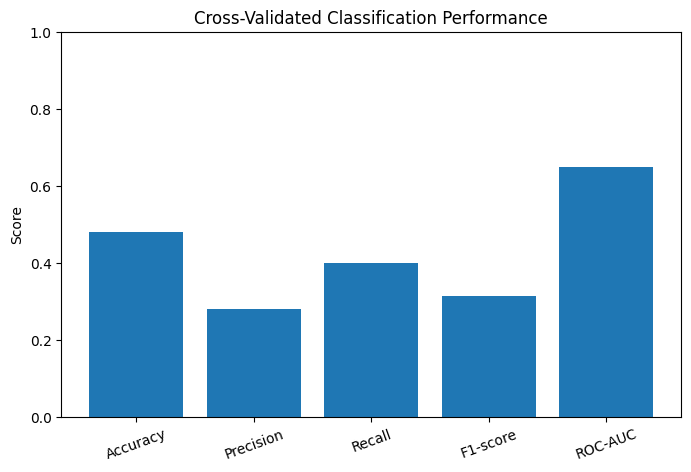

In [21]:
plt.figure(figsize=(8, 5))
plt.bar(results_df['Metric'], results_df['Mean'])
plt.title('Cross-Validated Classification Performance')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

## Step 11: Visual 2 — Confusion Matrix

The confusion matrix helps us understand how well the model distinguishes high-emission events from lower-emission events.

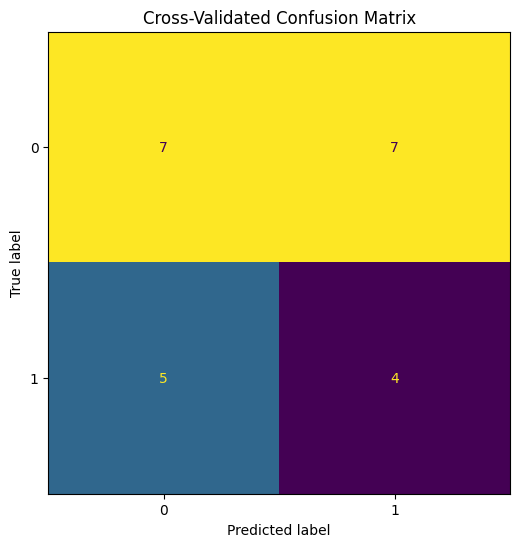

In [22]:
cm = confusion_matrix(y, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, colorbar=False)
plt.title('Cross-Validated Confusion Matrix')
plt.show()

## Step 12: Visual 3 — ROC Curve

The ROC curve shows how well the classifier separates high-emission and lower-emission events across different probability thresholds.

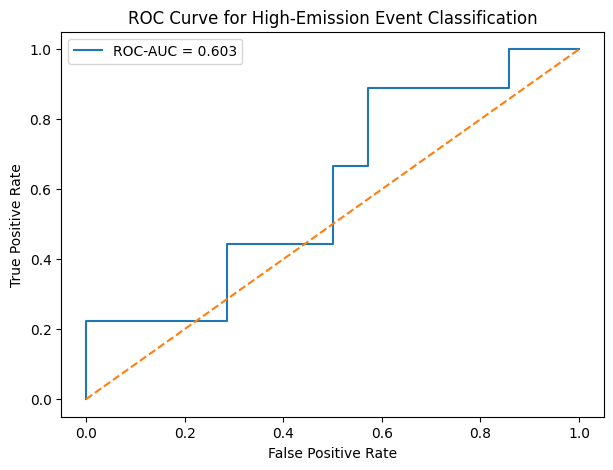

In [23]:
fpr, tpr, thresholds = roc_curve(y, y_proba)
roc_auc_value = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_value:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for High-Emission Event Classification')
plt.legend()
plt.show()

## Step 13: Standardized Feature Coefficients

Because Logistic Regression is interpretable, we can visualize which features push the model toward predicting a high-emission event.

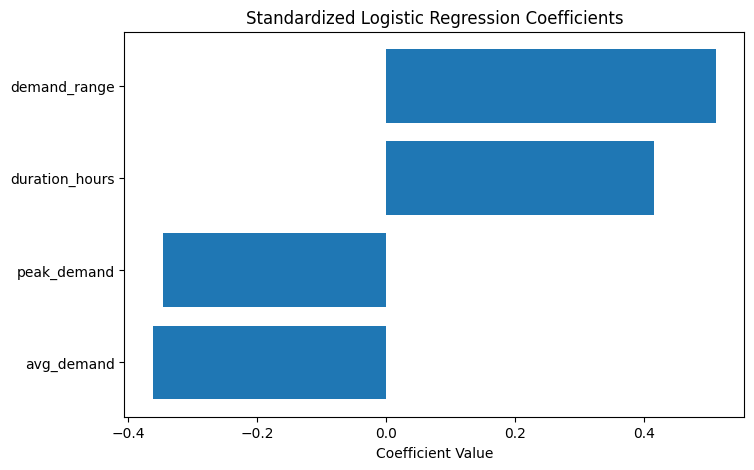

In [24]:
plt.figure(figsize=(8, 5))
plt.barh(coef_df['Feature'], coef_df['Coefficient'])
plt.title('Standardized Logistic Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.show()

## Visual  Predicted Probability Ranking of Events

This plot ranks all detected events by the model’s predicted probability of being a high-emission event. It shows whether the classifier meaningfully separates low-emission and high-emission events, rather than only reporting summary metrics.

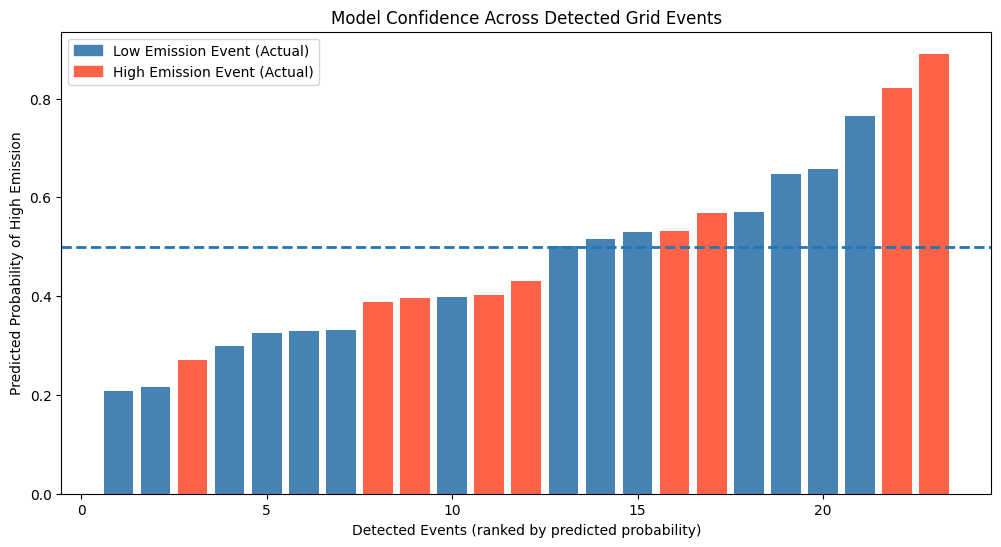

In [32]:
# Cross-validated predicted probabilities
import matplotlib.patches as mpatches

blue_patch = mpatches.Patch(color='steelblue', label='Low Emission Event (Actual)')
red_patch = mpatches.Patch(color='tomato', label='High Emission Event (Actual)')


y_proba = cross_val_predict(model, X, y, cv=cv, method='predict_proba')[:, 1]

viz_df = event_features.copy()
viz_df['actual_class'] = y.values
viz_df['pred_prob_high_emission'] = y_proba
viz_df = viz_df.sort_values('pred_prob_high_emission').reset_index(drop=True)
viz_df['event_rank'] = np.arange(1, len(viz_df) + 1)

plt.figure(figsize=(12, 6))

colors = viz_df['actual_class'].map({0: 'steelblue', 1: 'tomato'})
plt.bar(viz_df['event_rank'], viz_df['pred_prob_high_emission'], color=colors)

plt.axhline(0.5, linestyle='--', linewidth=2, label='Decision Threshold = 0.5')
plt.xlabel('Detected Events (ranked by predicted probability)')
plt.ylabel('Predicted Probability of High Emission')
plt.title('Model Confidence Across Detected Grid Events')
plt.legend(handles=[blue_patch, red_patch])
plt.show()

## Visual 2: Operational Drivers of High-Emission Events

This plot shows the standardized logistic regression coefficients, indicating which event features increase or decrease the probability of a detected event being classified as high-emission.

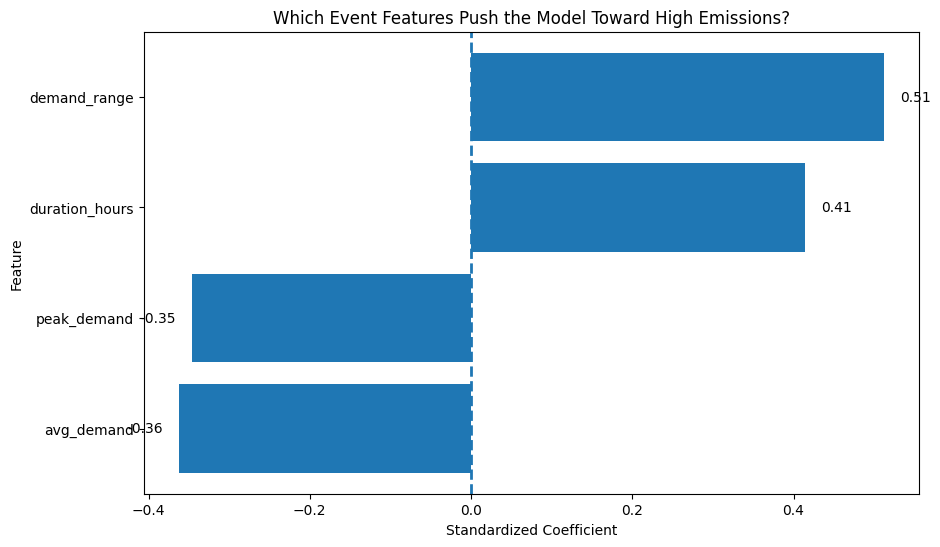

In [33]:
scoef_values = model.named_steps['clf'].coef_[0]

coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coef_values
}).sort_values('Coefficient')

plt.figure(figsize=(10, 6))
bars = plt.barh(coef_df['Feature'], coef_df['Coefficient'])

for i, v in enumerate(coef_df['Coefficient']):
    plt.text(v + (0.02 if v >= 0 else -0.02), i, f"{v:.2f}",
             va='center',
             ha='left' if v >= 0 else 'right')

plt.axvline(0, linestyle='--', linewidth=2)
plt.xlabel('Standardized Coefficient')
plt.ylabel('Feature')
plt.title('Which Event Features Push the Model Toward High Emissions?')
plt.show()